# Обзор результатов


In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

root = Path.cwd()
if not (root / "report_results").exists():
    for p in root.parents:
        if (p / "report_results").exists():
            root = p
            break

table_dir = root / "report_results" / "tables"
fig_dir = root / "report_results" / "figures"

pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 90)

def read_table(name):
    return pd.read_csv(table_dir / name)

def show_img(name):
    p = fig_dir / name
    if p.exists():
        display(Image(filename=str(p)))


## 1. Все найденные запуски

Сначала смотрю, сколько run-папок вообще попало в сводку и какие задачи есть в логах.


In [2]:
runs = read_table("all_runs_normalized.csv")
overview = read_table("task_overview.csv")
quality = read_table("run_quality.csv")

summary = pd.DataFrame({
    "метрика": ["всего запусков", "валидных", "плохих или невалидных", "задачи", "dtype"],
    "значение": [
        len(runs),
        int(runs["is_valid"].sum()),
        int(runs["is_bad"].sum()),
        ", ".join(sorted(runs["task_name"].dropna().unique())),
        ", ".join(sorted(runs["dtype"].dropna().unique())),
    ],
})
display(summary)


,метрика,значение
0,всего запусков,439
1,валидных,415
2,плохих или невалидных,240
3,задачи,"burgers1d, convection1d, heat1d, helmholtz1d"
4,dtype,"fp16, fp32, fp64"


In [3]:
cols = [
    "task_name", "main_parameter_name", "main_parameter_value", "dtype",
    "n_total", "n_valid", "n_bad", "median_best_l2", "bad_rate",
]
display(overview[cols].sort_values(["task_name", "main_parameter_value", "dtype"]).head(80))


,task_name,main_parameter_name,main_parameter_value,dtype,n_total,n_valid,n_bad,median_best_l2,bad_rate
0,burgers1d,nu,0.0001,fp32,2,1,2,0.391018,1.000000
1,burgers1d,nu,0.0001,fp64,2,2,2,0.413677,1.000000
2,burgers1d,nu,0.0002,fp32,2,2,2,0.397256,1.000000
3,burgers1d,nu,0.0002,fp64,2,2,2,0.408756,1.000000
4,burgers1d,nu,0.0005,fp32,2,2,2,0.385514,1.000000
5,burgers1d,nu,0.0005,fp64,2,2,2,0.383942,1.000000
6,burgers1d,nu,0.0010,fp16,2,0,2,NaN,1.000000
7,burgers1d,nu,0.0010,fp32,16,15,13,0.230167,0.812500
8,burgers1d,nu,0.0010,fp64,16,16,9,0.232790,0.562500
9,burgers1d,nu,0.0020,fp16,2,0,2,NaN,1.000000


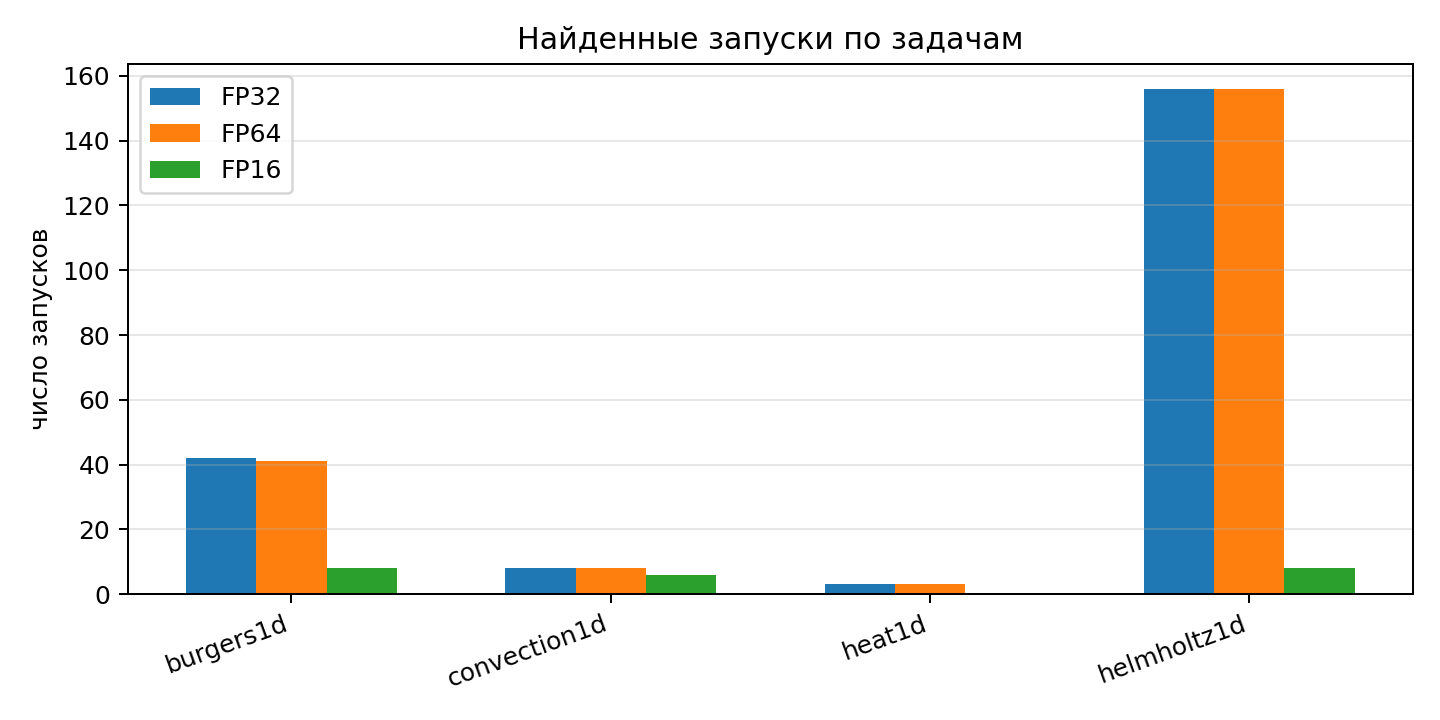

In [4]:
show_img("report_task_overview.png")


В логах есть много старых пробных запусков, поэтому плохих запусков довольно много. Я их не удаляю: они важны, чтобы не делать вывод по одному удачному seed.


## 2. Heat как простая проверка

Heat оставлен как простая задача. Здесь не ожидается драматической разницы между FP32 и FP64.


In [5]:
main_cases = read_table("report_main_cases.csv")
heat = main_cases[main_cases["task"] == "heat1d"]
display(heat[[
    "case_id", "parameter", "n_seed_fp32", "n_seed_fp64",
    "fp32_median_best_l2", "fp64_median_best_l2", "ratio", "comment",
]])


,case_id,parameter,n_seed_fp32,n_seed_fp64,fp32_median_best_l2,fp64_median_best_l2,ratio,comment
0,heat_alpha01,alpha=0.1,3.0,3.0,0.000375,0.000311,0.827905,На простой heat-задаче обе точности работают хорошо. Это простая проверка всей схемы о...


Heat нужен скорее как простая проверка: обе точности дают нормальный результат, поэтому дальше можно смотреть на более сложные PDE.


## 3. Helmholtz - основной блок

Главная часть отчёта строится вокруг Helmholtz. Здесь есть несколько сопоставимых запусков, где FP64 даёт меньшую медианную ошибку, и это не держится на одном seed.


In [6]:
helm = read_table("report_helmholtz_cases.csv")
display(helm[[
    "case_id", "parameter", "variant", "n_seed_fp32", "n_seed_fp64",
    "fp32_median_best_l2", "fp64_median_best_l2", "ratio",
    "bad_rate_fp32", "bad_rate_fp64", "comment",
]])


,case_id,parameter,variant,n_seed_fp32,n_seed_fp64,fp32_median_best_l2,fp64_median_best_l2,ratio,bad_rate_fp32,bad_rate_fp64,comment
0,helmholtz_m12_long,m=12,helmholtz_resample_long,2,2,0.012531,0.002114,0.168675,0.0,0.0,"В этом запуске есть по два валидных seed, и медиана FP64 заметно ниже медианы FP32."
1,helmholtz_m12_rs,m=12,helmholtz_rs_m12,2,2,0.002160,0.000834,0.386118,0.0,0.0,Ещё один устойчивый m=12 с ресемплированием. FP64 снова даёт меньшую медианную ошибку.
2,helmholtz_m12_resample128,m=12,resample_proven_128,2,2,0.009213,0.002114,0.229403,0.0,0.0,Похожая настройка с более длинным L-BFGS. Вывод совпадает с основным m=12.
3,helmholtz_m7_rs,m=7,helmholtz_rs_m7,2,2,0.001348,0.000514,0.381523,0.0,0.0,На меньшем m результат тоже чистый: оба dtype имеют по два валидных seed.
4,helmholtz_m8_rs,m=8,helmholtz_rs_m8,2,2,0.002536,0.001039,0.409678,0.0,0.0,"Это не старый unstable m=8, а более аккуратный rs-запуск без плохих seed."
5,helmholtz_m11_rs,m=11,helmholtz_rs_m11,2,2,0.001906,0.000983,0.516015,0.0,0.0,"FP64 лучше по медиане, но отрыв меньше, чем на m=12."
6,helmholtz_m10_resample128,m=10,resample_proven_128,2,2,0.002986,0.001513,0.506824,0.0,0.0,Можно использовать как вспомогательный пример: FP64 лучше не так резко.
7,helmholtz_m10_initial,m=10,helmholtz_m10,2,2,0.053347,0.024447,0.458264,0.0,0.0,"Старый запуск m=10 полезен как дополнительная проверка, но не главный результат."


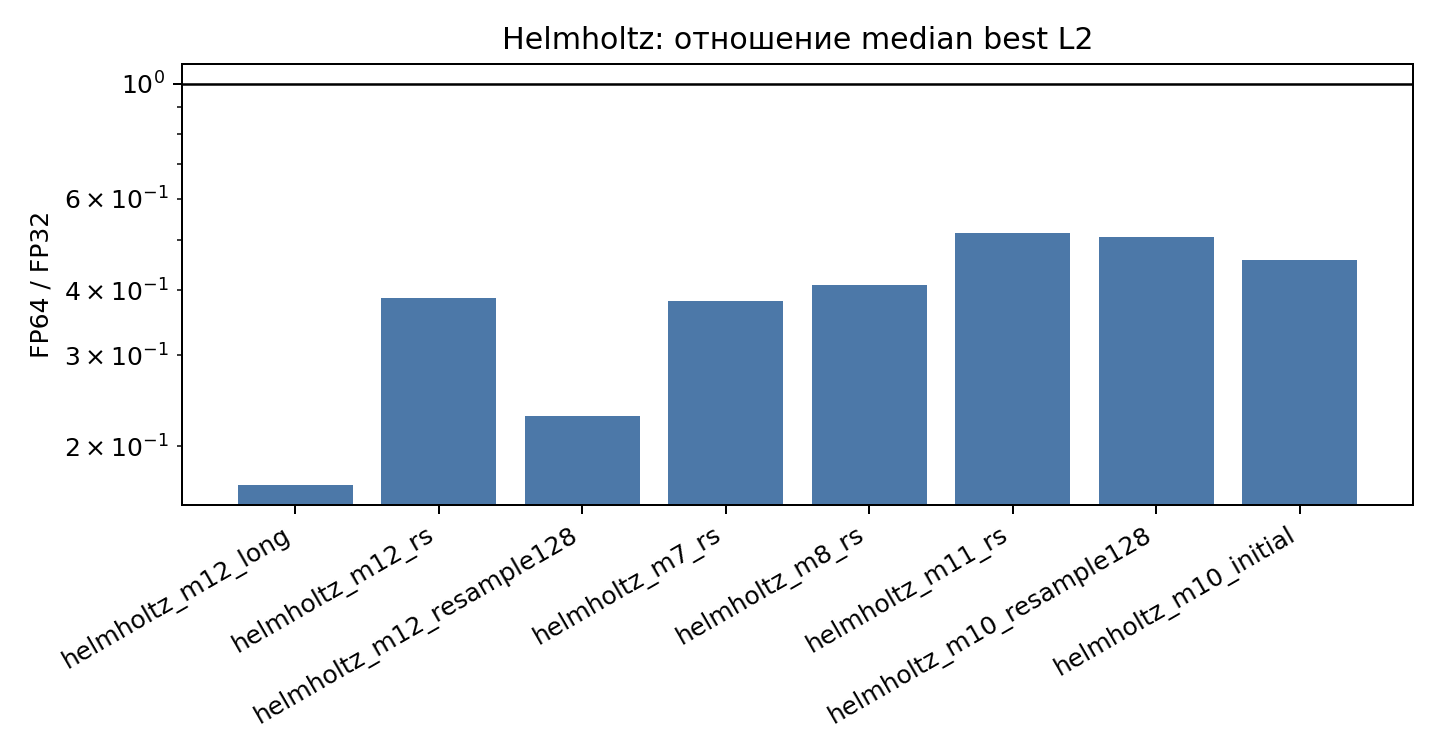

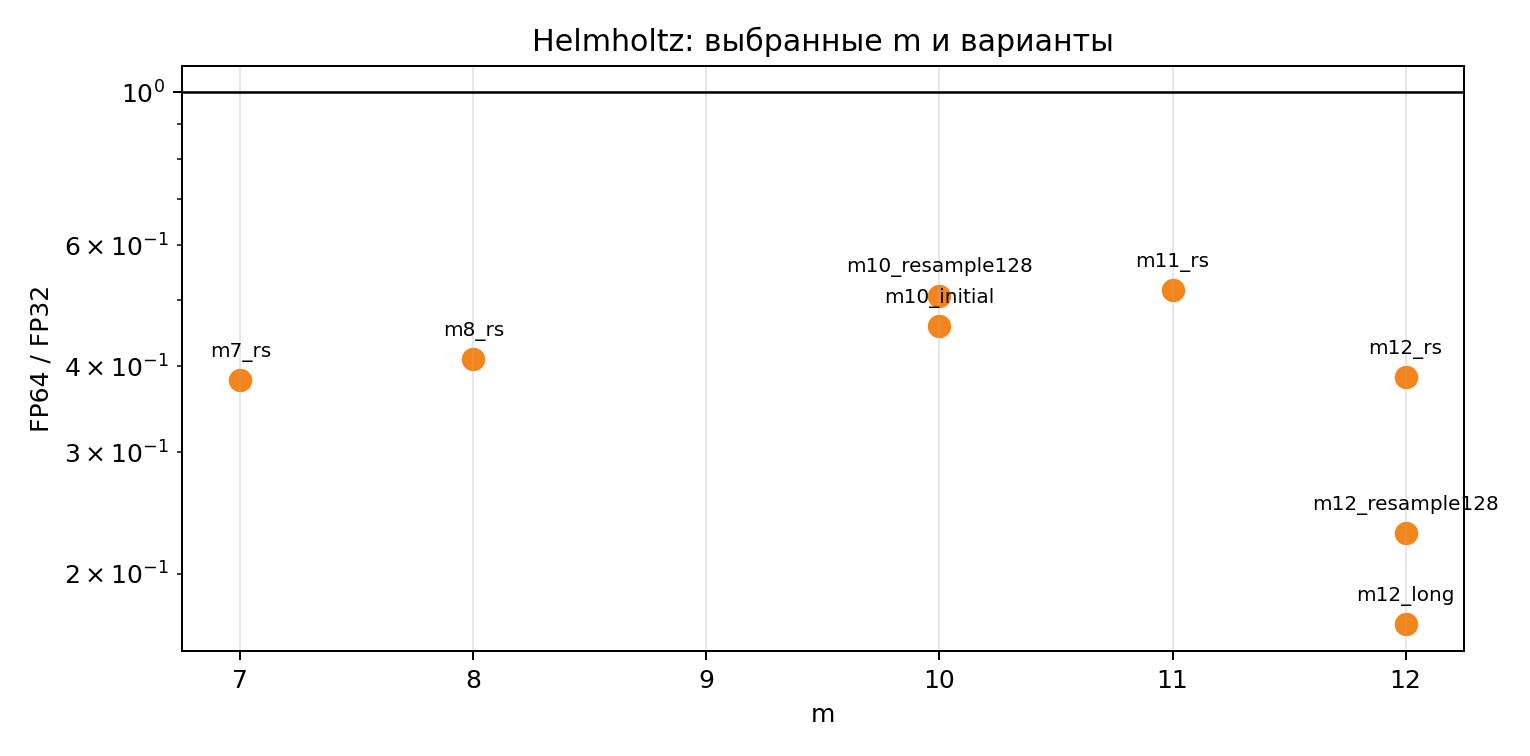

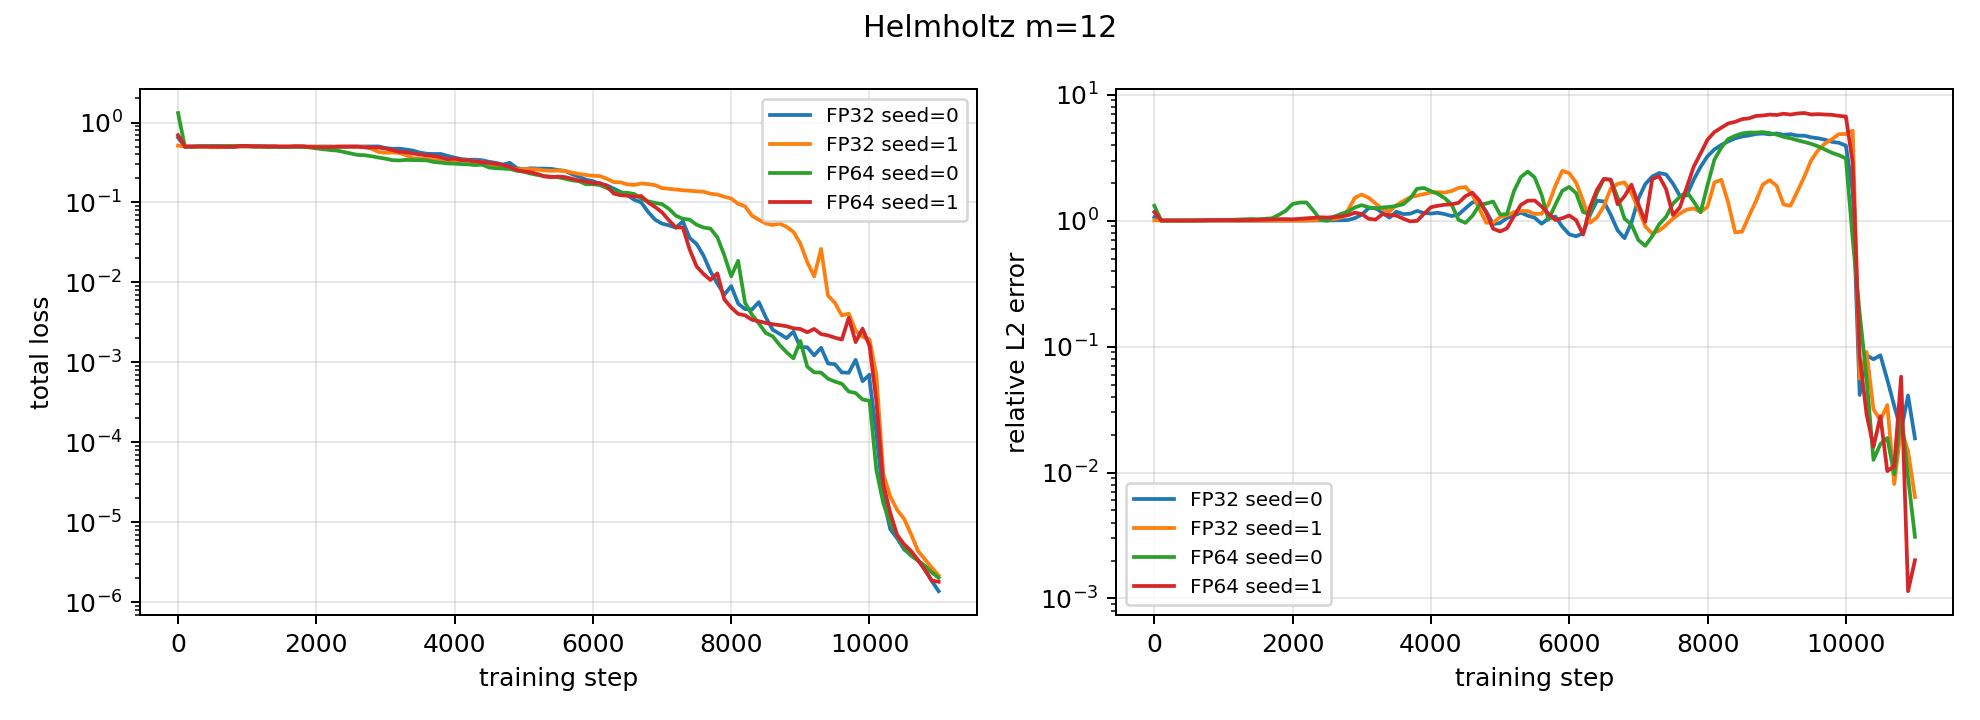

In [7]:
show_img("report_helmholtz_main_ratio.png")
show_img("report_helmholtz_rs_sweep.png")
show_img("report_helmholtz_m12_curves.png")


In [8]:
comp = read_table("fp32_fp64_comparison.csv")
helm_all = comp[comp["task_name"] == "helmholtz1d"].copy()
helm_all = helm_all[
    helm_all["main_parameter_value"].isin([5, 7, 8, 10, 11, 12, 15, 20, 30, 40])
]
cols = [
    "main_parameter_value", "variant", "fp32_n_valid", "fp64_n_valid",
    "fp32_median_best_l2", "fp64_median_best_l2", "fp64_over_fp32_median",
    "fp32_bad_rate", "fp64_bad_rate", "conclusion",
]
display(helm_all[cols].sort_values(["main_parameter_value", "variant"]).head(40))


,main_parameter_value,variant,fp32_n_valid,fp64_n_valid,fp32_median_best_l2,fp64_median_best_l2,fp64_over_fp32_median,fp32_bad_rate,fp64_bad_rate,conclusion
66,5.0,helmholtz_m5,2,2,0.000082,0.000059,0.721432,0.0,0.0,moderate_fp64_better
67,5.0,helmholtz_m5,2,2,0.001769,0.000634,0.358395,0.0,0.0,stable_fp64_better
76,5.0,helmholtz_rs_m5,2,2,0.000150,0.000478,3.181760,0.0,0.0,fp32_better
78,7.0,helmholtz_rs_m7,2,2,0.001348,0.000514,0.381523,0.0,0.0,stable_fp64_better
37,8.0,adam_only,2,2,0.249723,0.180629,0.723317,0.5,0.5,seed_sensitive
42,8.0,base_2k,2,2,0.005320,0.500547,94.095203,0.0,0.5,seed_sensitive
47,8.0,helmholtz_lbfgs_r01_m8_fp32_adam0,1,0,1.016898,NaN,NaN,1.0,NaN,insufficient_data
48,8.0,helmholtz_lbfgs_r02_m8_fp64_adam0,0,1,NaN,0.999859,NaN,NaN,1.0,insufficient_data
49,8.0,helmholtz_lbfgs_r03_m8_fp32_adam500,1,0,0.000214,NaN,NaN,0.0,NaN,insufficient_data
50,8.0,helmholtz_lbfgs_r04_m8_fp64_adam500,0,1,NaN,1.012048,NaN,NaN,1.0,insufficient_data


Для основного текста лучше брать чистые Helmholtz-строки из `report_helmholtz_cases.csv`. Старый `helmholtz_main m=8` и очень большие `m` полезнее обсуждать как нестабильные режимы, а не как главное доказательство.


## 4. Burgers

Burgers получился смешанным. Здесь не видно чистой истории, что FP64 всегда лучше FP32.


In [9]:
burg = comp[comp["task_name"] == "burgers1d"].copy()
cols = [
    "main_parameter_value", "variant", "fp32_n_valid", "fp64_n_valid",
    "fp32_median_best_l2", "fp64_median_best_l2", "fp64_over_fp32_median",
    "fp32_bad_rate", "fp64_bad_rate", "conclusion",
]
display(burg[cols].sort_values(["main_parameter_value", "variant"]).head(60))


,main_parameter_value,variant,fp32_n_valid,fp64_n_valid,fp32_median_best_l2,fp64_median_best_l2,fp64_over_fp32_median,fp32_bad_rate,fp64_bad_rate,conclusion
11,0.0001,burgers_hard_nu_0p0001,1,2,0.391018,0.413677,1.057949,1.0,1.0,seed_sensitive
12,0.0002,burgers_hard_nu_0p0002,2,2,0.397256,0.408756,1.028948,1.0,1.0,seed_sensitive
13,0.0005,burgers_hard_nu_0p0005,2,2,0.385514,0.383942,0.995923,1.0,1.0,seed_sensitive
0,0.0010,adam1e4_lbfgs05_steps2000_inner5_resample200,1,1,0.176781,0.185780,1.050904,0.0,0.0,seed_sensitive
1,0.0010,adam1e4_lbfgs1_steps2000_inner5_resample200,1,1,0.220319,0.178767,0.811399,1.0,0.0,seed_sensitive
2,0.0010,adam2e4_lbfgs05_steps2000_inner5_resample200,1,1,0.226545,0.230192,1.016099,1.0,1.0,seed_sensitive
3,0.0010,adam2e4_lbfgs1_steps2000_inner5_resample200,1,1,0.225579,0.267399,1.185391,1.0,1.0,seed_sensitive
4,0.0010,adam3000_lbfgs5000_inner5_resample200,1,1,0.270881,0.099582,0.367622,1.0,0.0,seed_sensitive
7,0.0010,adam5e4_lbfgs05_steps2000_inner5_resample200,1,1,0.233625,0.078599,0.336433,1.0,0.0,seed_sensitive
9,0.0010,adam5e4_lbfgs1_steps2000_inner5_resample200,1,1,0.270881,0.099582,0.367622,1.0,0.0,seed_sensitive


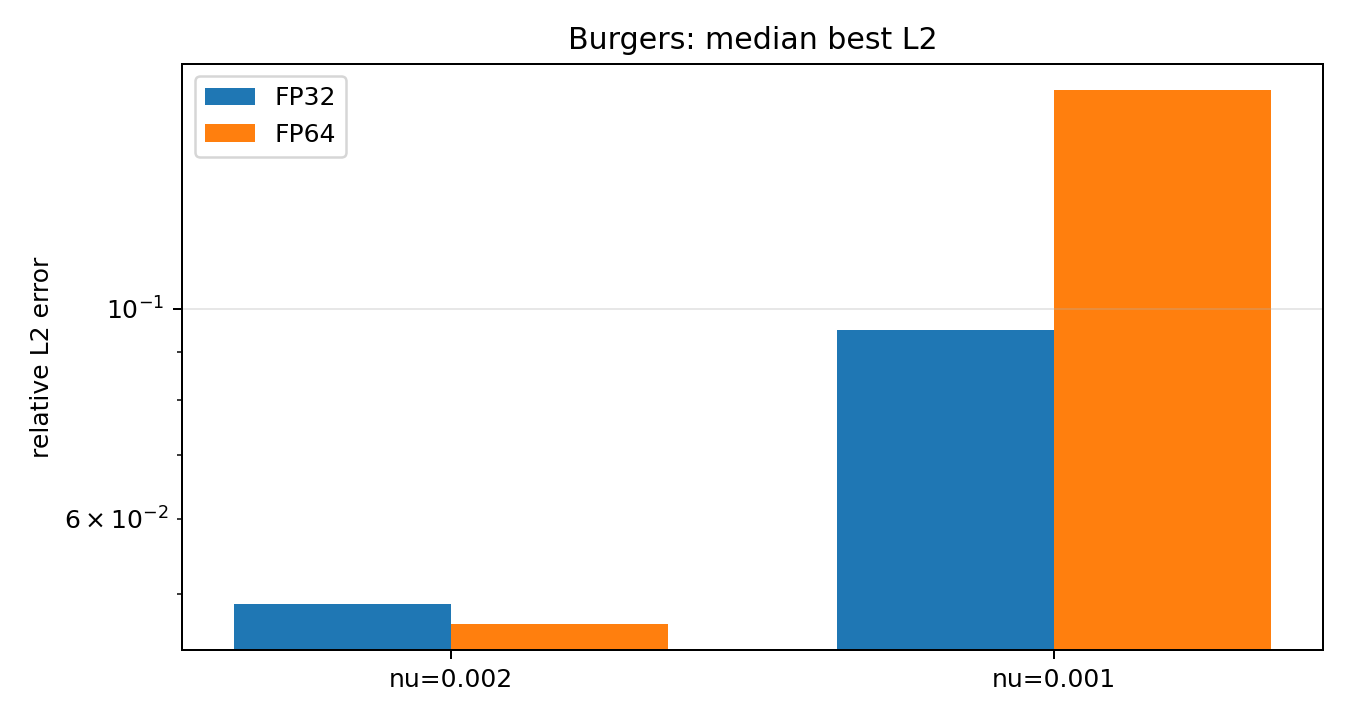

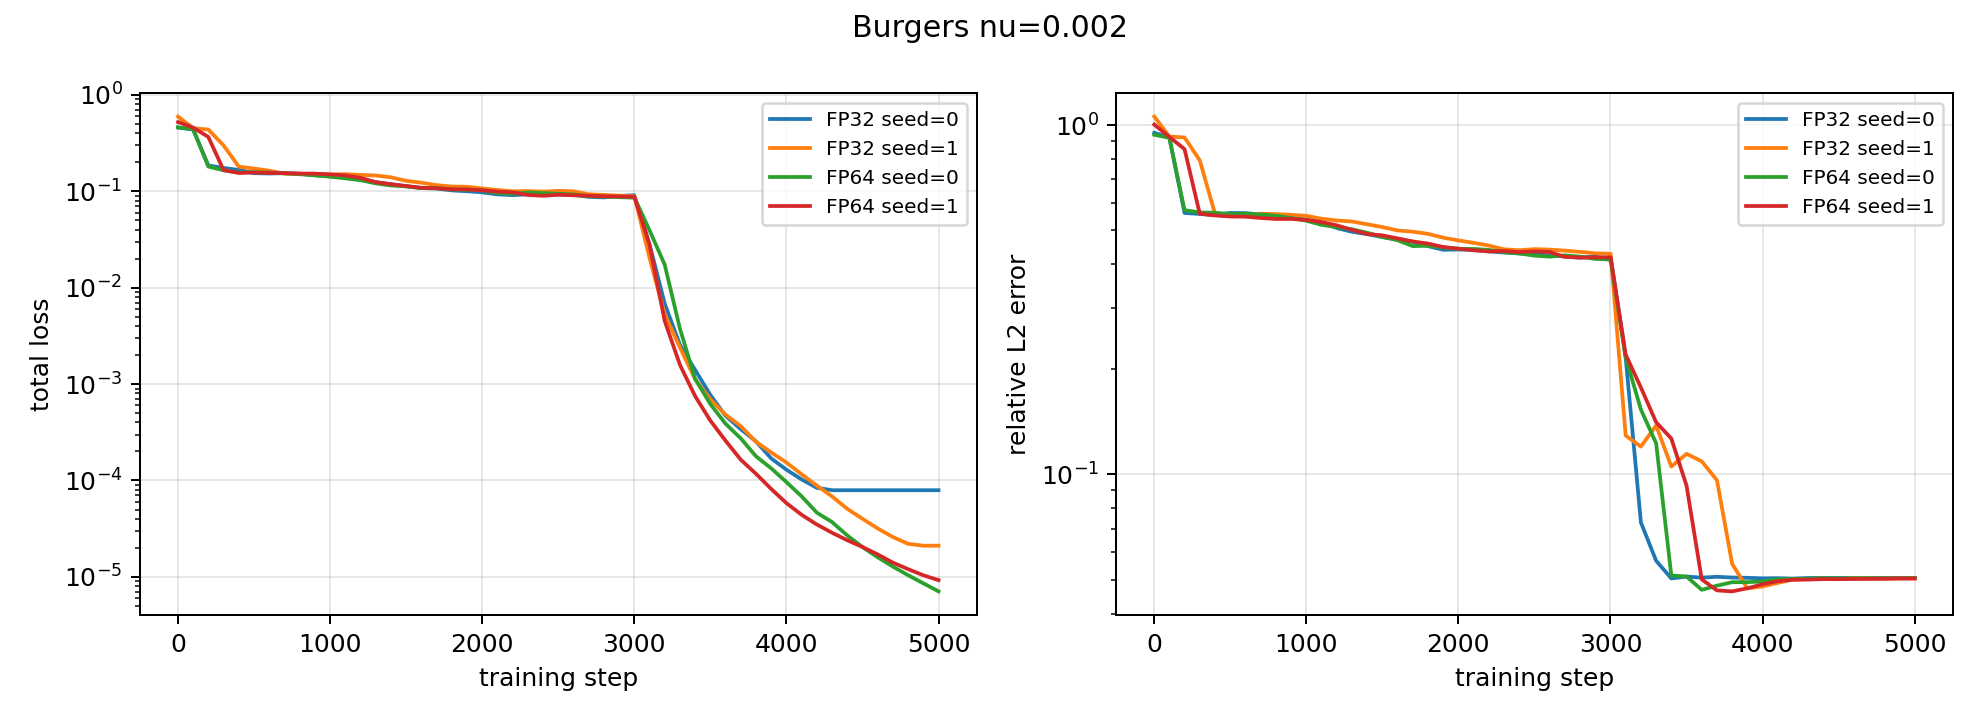

In [10]:
show_img("report_burgers_summary.png")
show_img("report_burgers_nu0002_curves.png")


Burgers я оставляю как смешанный или отрицательный блок. На части запусков FP32 и FP64 близки, а на `nu=0.001` FP64 не даёт преимущества по медиане.


## 5. Convection

In [11]:
conv = comp[comp["task_name"] == "convection1d"].copy()
cols = [
    "main_parameter_value", "variant", "fp32_n_valid", "fp64_n_valid",
    "fp32_median_best_l2", "fp64_median_best_l2", "fp64_over_fp32_median",
    "fp32_bad_rate", "fp64_bad_rate", "conclusion",
]
display(conv[cols].sort_values(["main_parameter_value", "variant"]).head(40))


,main_parameter_value,variant,fp32_n_valid,fp64_n_valid,fp32_median_best_l2,fp64_median_best_l2,fp64_over_fp32_median,fp32_bad_rate,fp64_bad_rate,conclusion
25,30.0,convection_beta30,2,2,1.000190,0.007463,0.007462,1.0,0.0,seed_sensitive
26,30.0,convection_beta30_lbfgs_grid,2,2,0.010941,0.006625,0.605541,0.0,0.0,moderate_fp64_better
29,30.0,lbfgs_grid_t4,1,1,0.006611,0.010181,1.539935,0.0,0.0,seed_sensitive
27,50.0,convection_beta50,1,1,0.741242,0.700409,0.944913,1.0,1.0,seed_sensitive
28,50.0,convection_beta50_wide_lbfgs,1,1,0.687307,0.007182,0.010449,1.0,0.0,single_seed_hard_case
30,50.0,lbfgs_grid_t4,1,1,0.850583,0.858125,1.008867,1.0,1.0,seed_sensitive


In [12]:
diag = read_table("report_diagnostic_cases.csv")
display(diag[[
    "case_id", "parameter", "variant", "n_seed_fp32", "n_seed_fp64",
    "fp32_median_best_l2", "fp64_median_best_l2", "ratio", "comment",
]])


,case_id,parameter,variant,n_seed_fp32,n_seed_fp64,fp32_median_best_l2,fp64_median_best_l2,ratio,comment
0,convection_beta50,beta=50,convection_beta50_wide_lbfgs,1,1,0.687307,0.007182,0.010449,"FP64 выглядит сильно лучше, но здесь только один seed. FP32 мог не сойтись из-за неуда..."
1,helmholtz_m8_main_old,m=8,helmholtz_main,2,2,0.501915,0.000881,0.001756,Старый m=8 показывает сильную зависимость от seed. Его полезно оставить как пример нес...
2,helmholtz_m15_helmholtz_m15,m=15,helmholtz_m15,2,2,0.999106,0.999802,1.000697,При большем m обе точности часто не сходились. Это уже скорее граница выбранной схемы ...


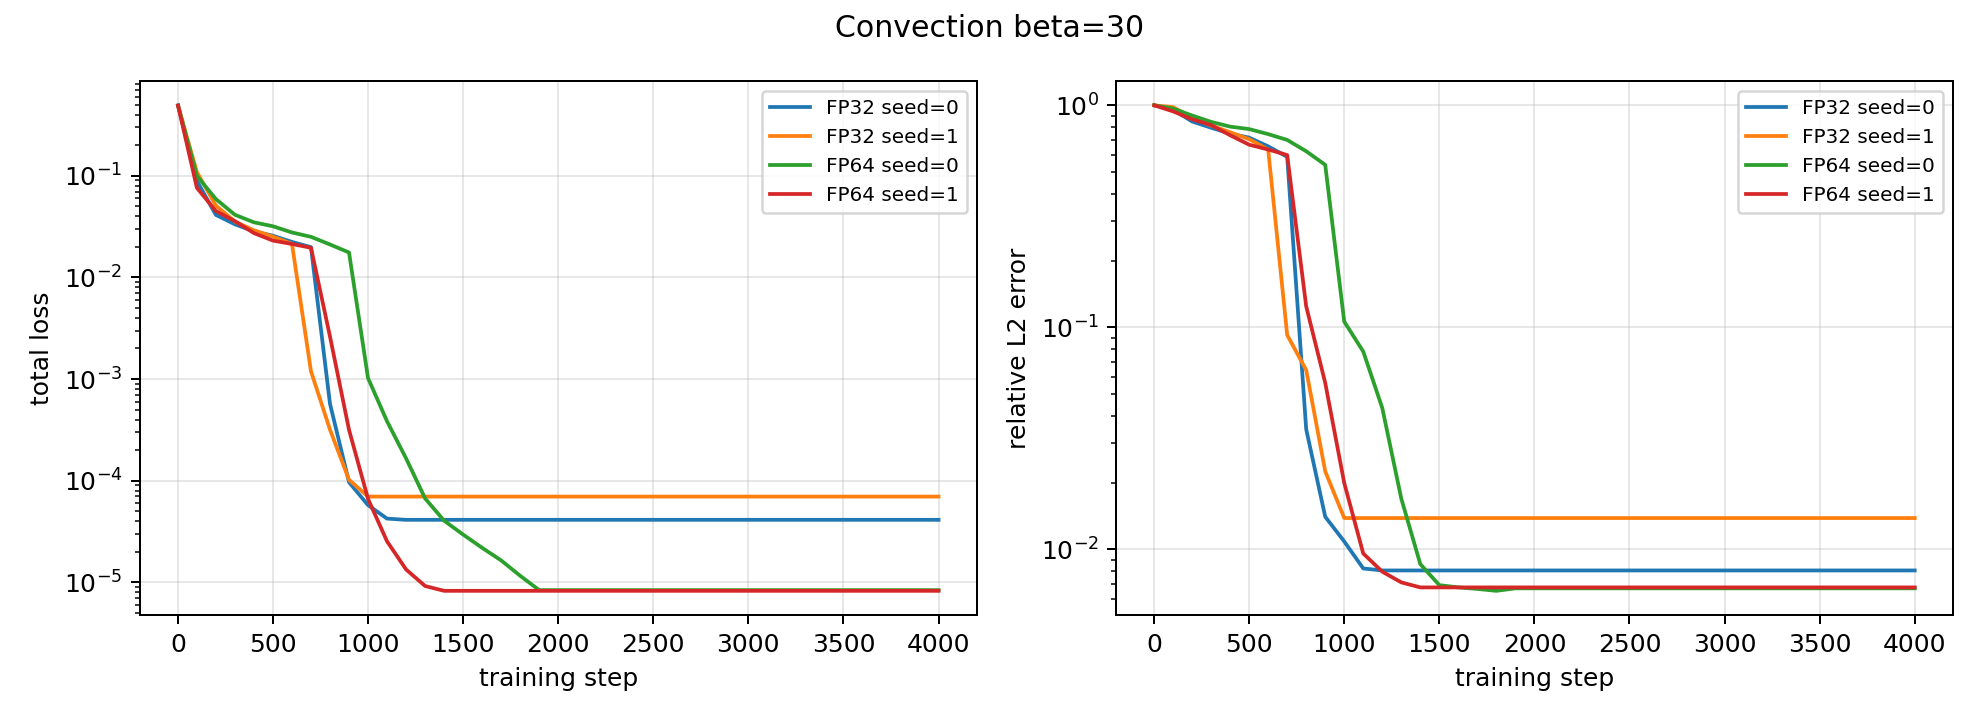

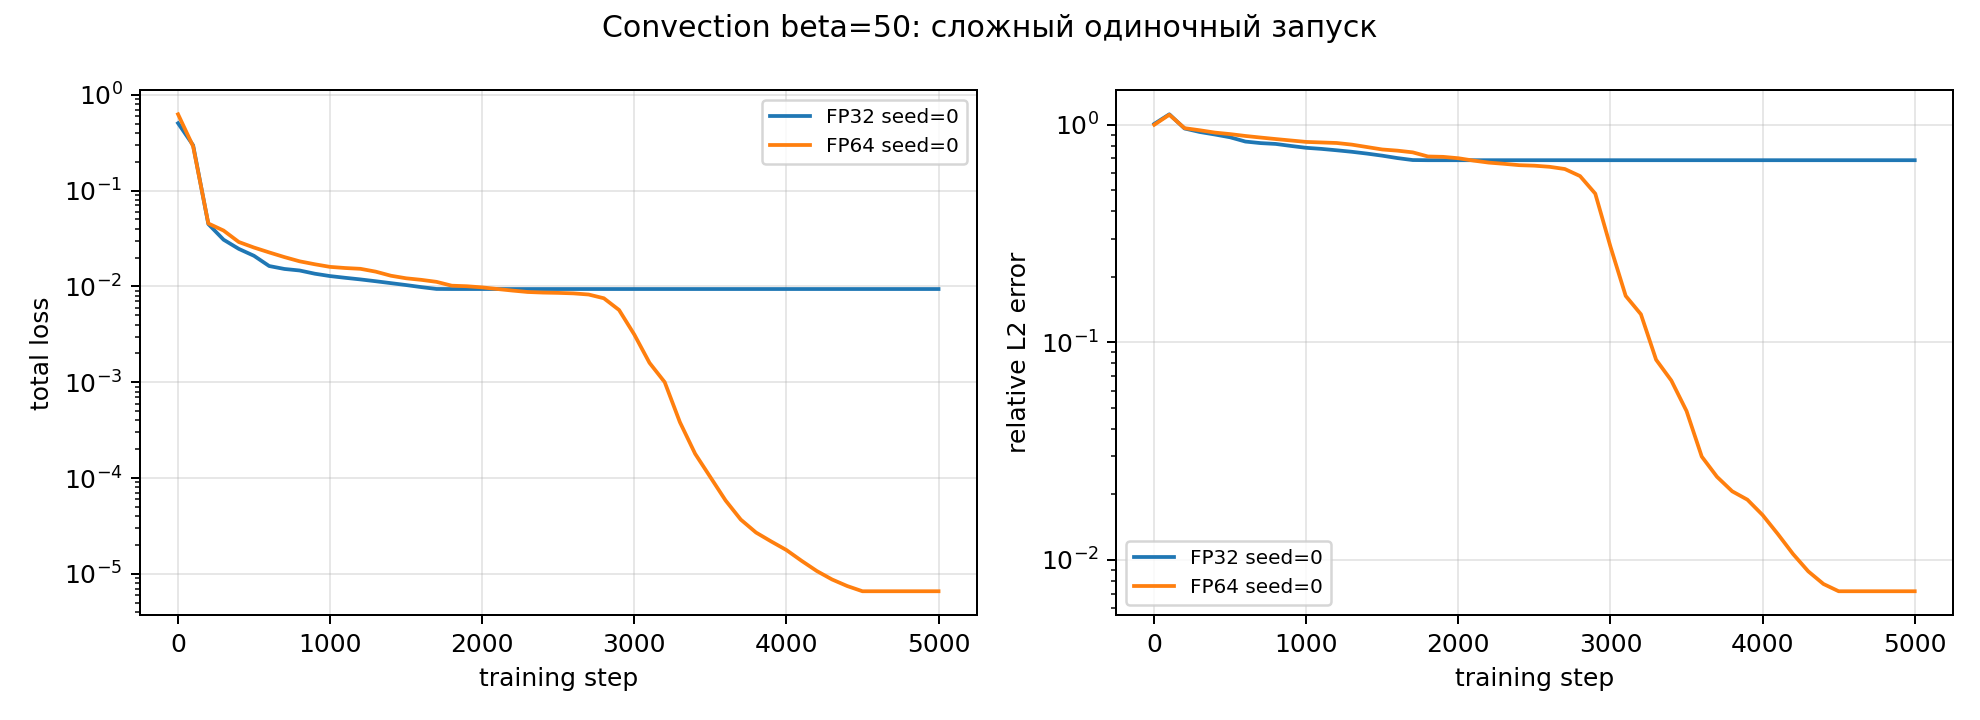

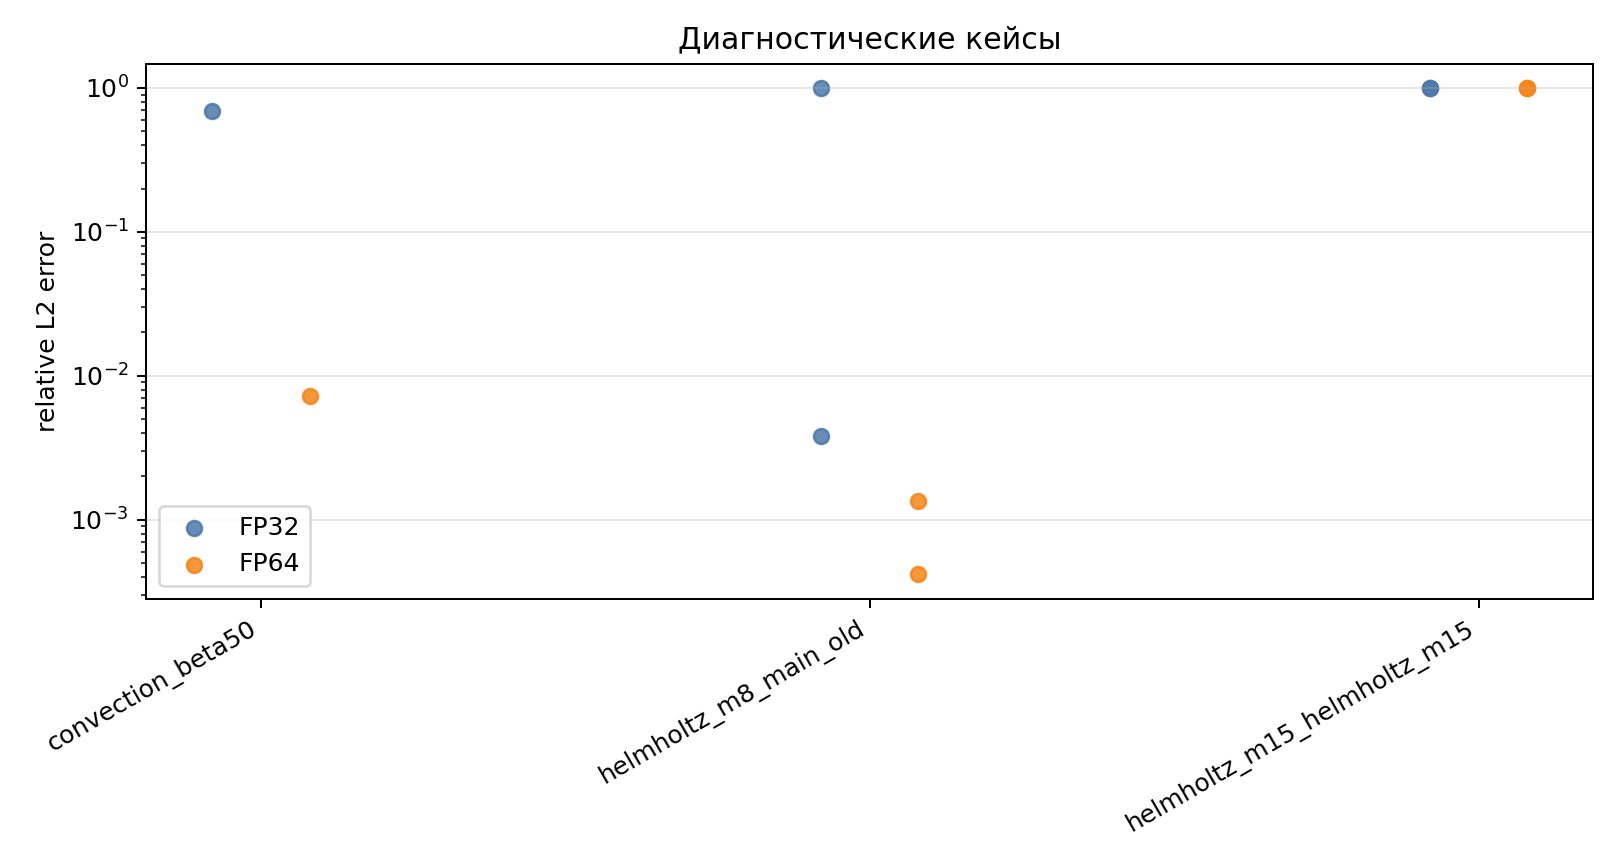

In [13]:
show_img("report_convection_beta30_curves.png")
show_img("report_convection_beta50_check.png")
show_img("report_diagnostic_seed_sensitive.png")


Convection beta=50 выглядит сильным примером, но там слишком мало seed. FP32 мог просто не начать сходиться из-за неудачной инициализации, поэтому этот кейс не используется как устойчивый основной вывод.


## 6. FP16

FP16 я не смешиваю с основной таблицей FP32/FP64. В этих запусках он чаще показывает нестабильность.


In [14]:
fp16 = read_table("fp16_summary.csv")
reason_col = fp16.columns[-1]
fp16_view = fp16[[
    "task_name", "main_parameter_name", "main_parameter_value", "variant",
    "n_total", "n_valid", "n_bad", "bad_rate",
    "best_l2_median", "final_l2_median", reason_col,
]].rename(columns={reason_col: "типичная причина"})
display(fp16_view)


,task_name,main_parameter_name,main_parameter_value,variant,n_total,n_valid,n_bad,bad_rate,best_l2_median,final_l2_median,типичная причина
0,burgers1d,nu,NaN,burgers_main_nu0p001,2,0,2,1.0,NaN,NaN,runtime_error
1,burgers1d,nu,NaN,burgers_main_nu0p002,2,0,2,1.0,NaN,NaN,runtime_error
2,burgers1d,nu,0.001,burgers_more_points,2,0,2,1.0,NaN,NaN,nan_metric
3,burgers1d,nu,0.002,burgers_more_points,2,0,2,1.0,NaN,NaN,nan_metric
4,convection1d,beta,NaN,convection_beta30_beta30p0,2,0,2,1.0,NaN,NaN,runtime_error
5,convection1d,beta,30.000,convection_beta30_lbfgs_grid,2,1,2,1.0,1.000977,1.000977,high_best_l2
6,convection1d,beta,NaN,convection_beta50_beta50p0,1,0,1,1.0,NaN,NaN,runtime_error
7,convection1d,beta,50.000,convection_beta50_wide_lbfgs,1,0,1,1.0,NaN,NaN,nan_metric
8,helmholtz1d,m,NaN,helmholtz_main_m12,2,0,2,1.0,NaN,NaN,runtime_error
9,helmholtz1d,m,NaN,helmholtz_main_m8,2,0,2,1.0,NaN,NaN,runtime_error


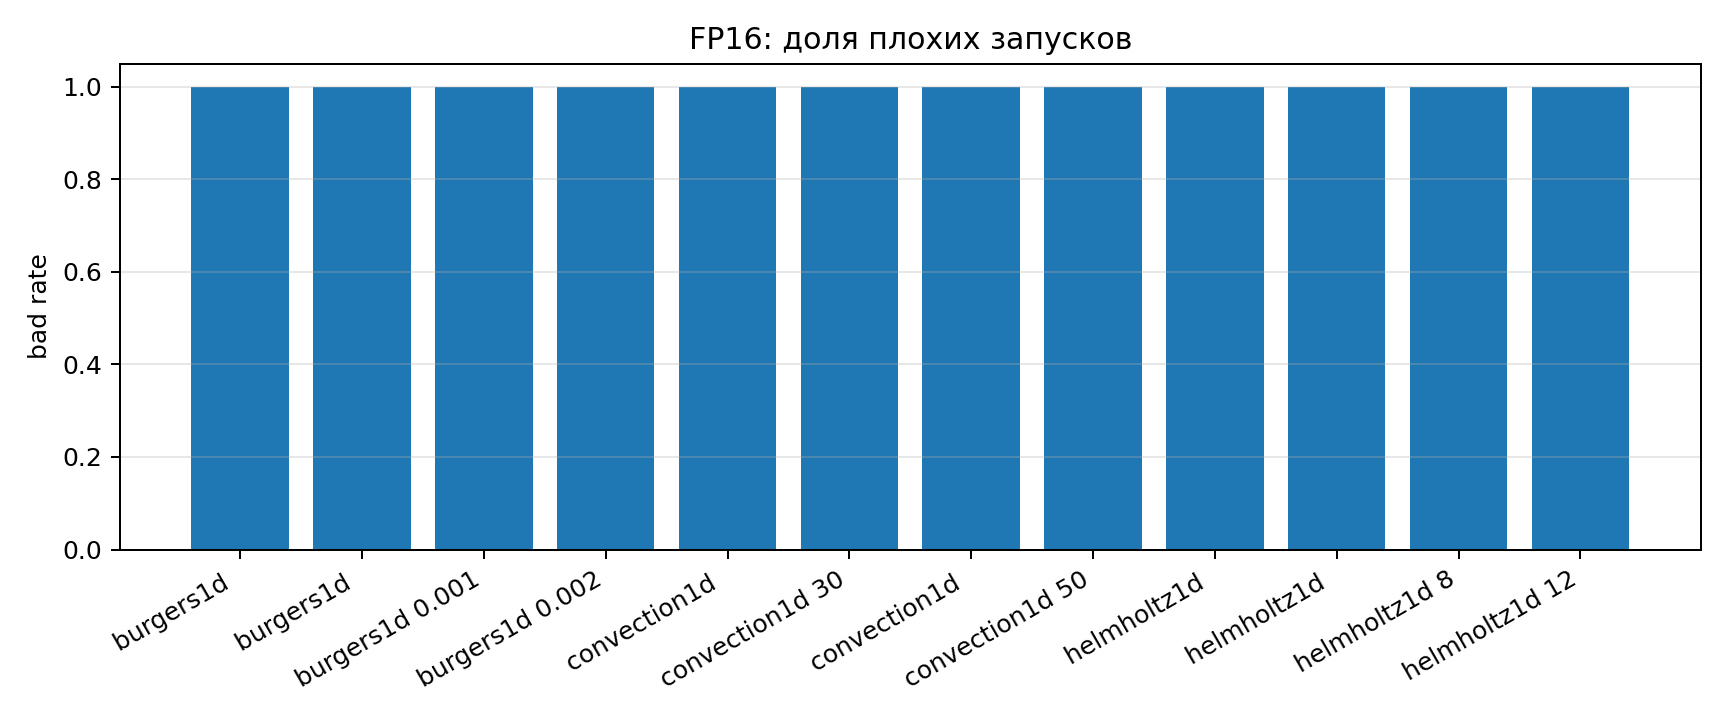

In [15]:
show_img("report_fp16_summary.png")


FP16 лучше оставить отдельным блоком про неудачные запуски, а не подавать как равноправный устойчивый базовый пример.


## 7. Итоговые кейсы для отчёта

Ниже компактная таблица для основного текста. В неё не включён `convection beta=50` как главный результат, потому что там недостаточно seed.


In [16]:
display(main_cases[[
    "case_id", "task", "parameter", "variant", "n_seed_fp32", "n_seed_fp64",
    "fp32_median_best_l2", "fp64_median_best_l2", "ratio",
    "bad_rate_fp32", "bad_rate_fp64", "label", "comment",
]])


,case_id,task,parameter,variant,n_seed_fp32,n_seed_fp64,fp32_median_best_l2,fp64_median_best_l2,ratio,bad_rate_fp32,bad_rate_fp64,label,comment
0,heat_alpha01,heat1d,alpha=0.1,heat1d,3.0,3.0,0.000375,0.000311,0.827905,0.0,0.0,проверка,На простой heat-задаче обе точности работают хорошо. Это простая проверка всей схемы о...
1,helmholtz_m12_long,helmholtz1d,m=12,helmholtz_resample_long,2.0,2.0,0.012531,0.002114,0.168675,0.0,0.0,главный положительный пример,"В этом запуске есть по два валидных seed, и медиана FP64 заметно ниже медианы FP32."
2,helmholtz_m12_rs,helmholtz1d,m=12,helmholtz_rs_m12,2.0,2.0,0.002160,0.000834,0.386118,0.0,0.0,дополнительный чистый пример,Ещё один устойчивый m=12 с ресемплированием. FP64 снова даёт меньшую медианную ошибку.
3,helmholtz_m12_resample128,helmholtz1d,m=12,resample_proven_128,2.0,2.0,0.009213,0.002114,0.229403,0.0,0.0,дополнительный чистый пример,Похожая настройка с более длинным L-BFGS. Вывод совпадает с основным m=12.
4,helmholtz_m7_rs,helmholtz1d,m=7,helmholtz_rs_m7,2.0,2.0,0.001348,0.000514,0.381523,0.0,0.0,положительный пример,На меньшем m результат тоже чистый: оба dtype имеют по два валидных seed.
5,helmholtz_m11_rs,helmholtz1d,m=11,helmholtz_rs_m11,2.0,2.0,0.001906,0.000983,0.516015,0.0,0.0,умеренно положительный пример,"FP64 лучше по медиане, но отрыв меньше, чем на m=12."
6,convection_beta30,convection1d,beta=30,convection_beta30_lbfgs_grid,2.0,2.0,0.010941,0.006625,0.605541,0.0,0.0,аккуратный пример convection,"Есть по два seed у FP32 и FP64. FP64 лучше умеренно, без истории про полный провал FP32."
7,burgers_nu0p002,burgers1d,nu=0.002,burgers_more_points,2.0,2.0,0.048779,0.046524,0.953769,0.0,0.0,результаты близкие,Burgers nu=0.002 показывает близкие результаты FP32 и FP64.
8,burgers_nu0p001,burgers1d,nu=0.001,burgers_more_points,2.0,2.0,0.094845,0.169969,1.792065,0.0,0.0,смешанный результат,На этом Burgers-запуске FP64 не даёт устойчивого преимущества. Это полезный отрицатель...
9,fp16_summary,fp16,все fp16-запуски,отдельно,NaN,NaN,NaN,NaN,NaN,NaN,NaN,FP16 нестабилен,FP16 вынесен отдельно: 22/22 запусков плохие или невалидные.


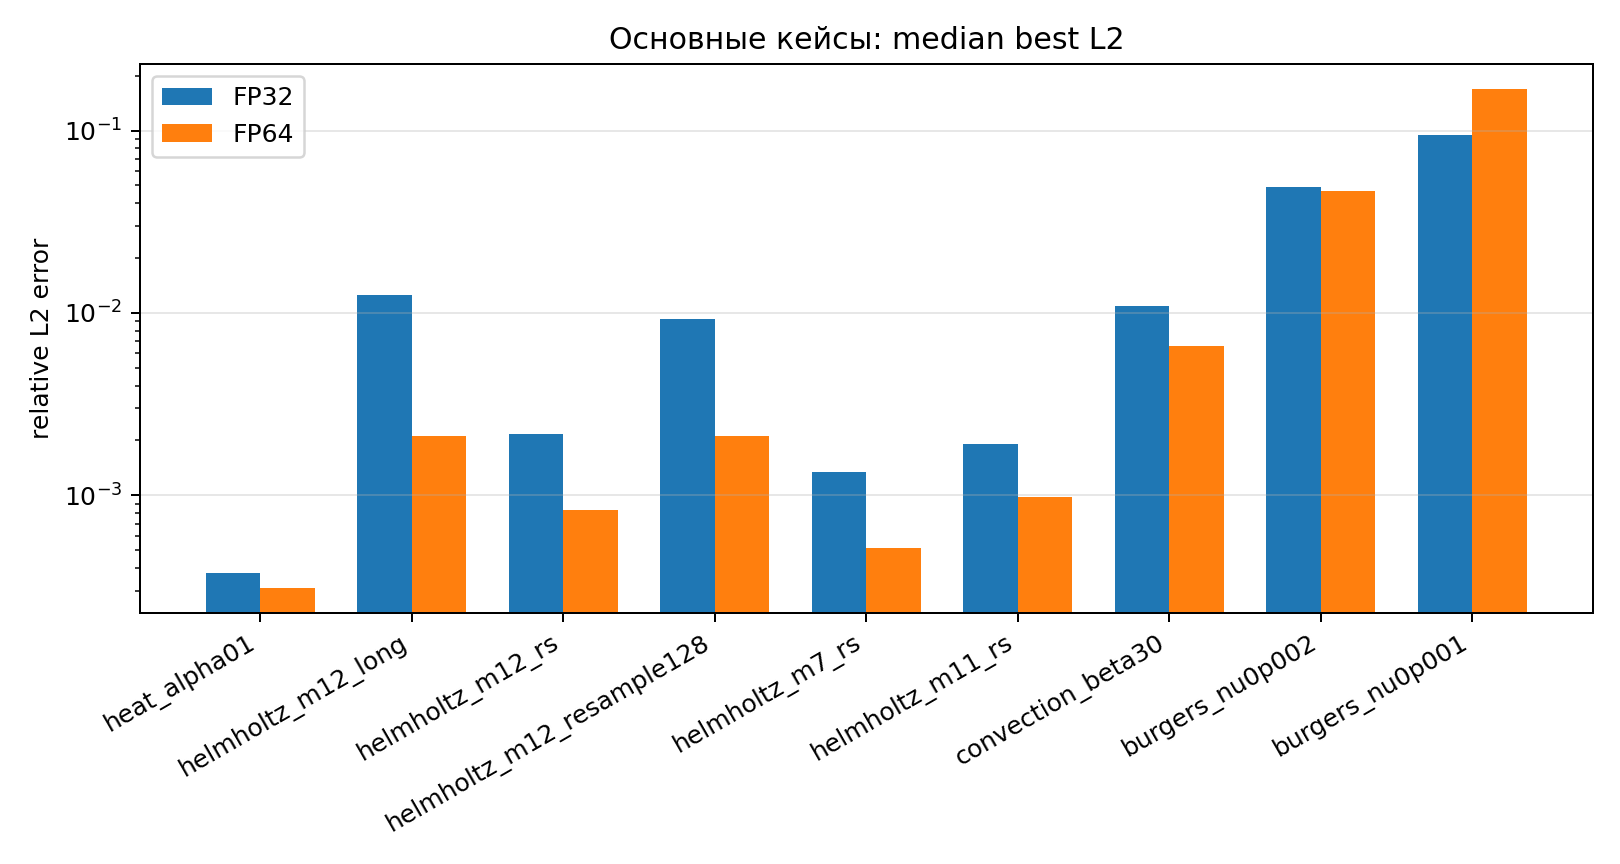

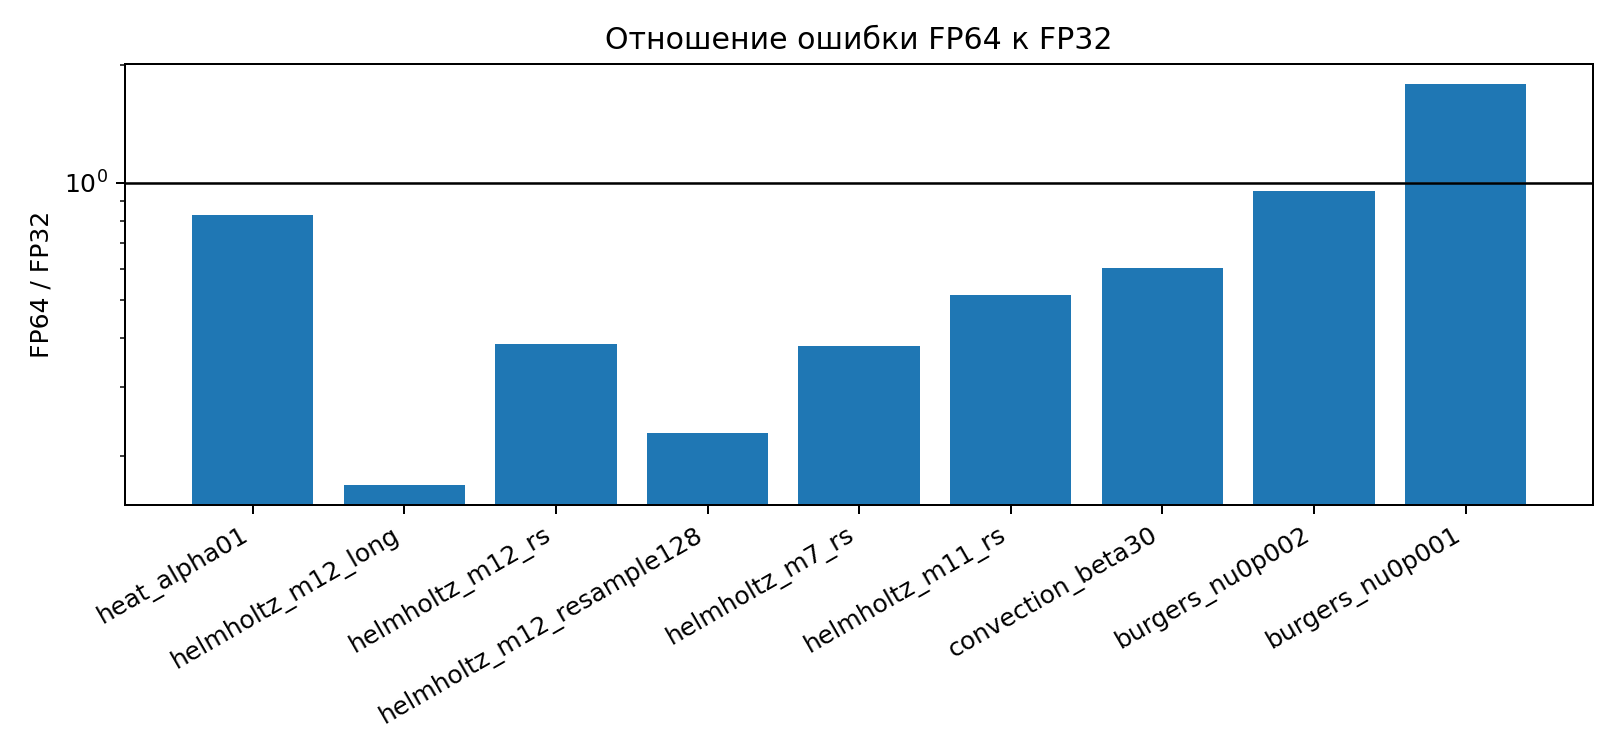

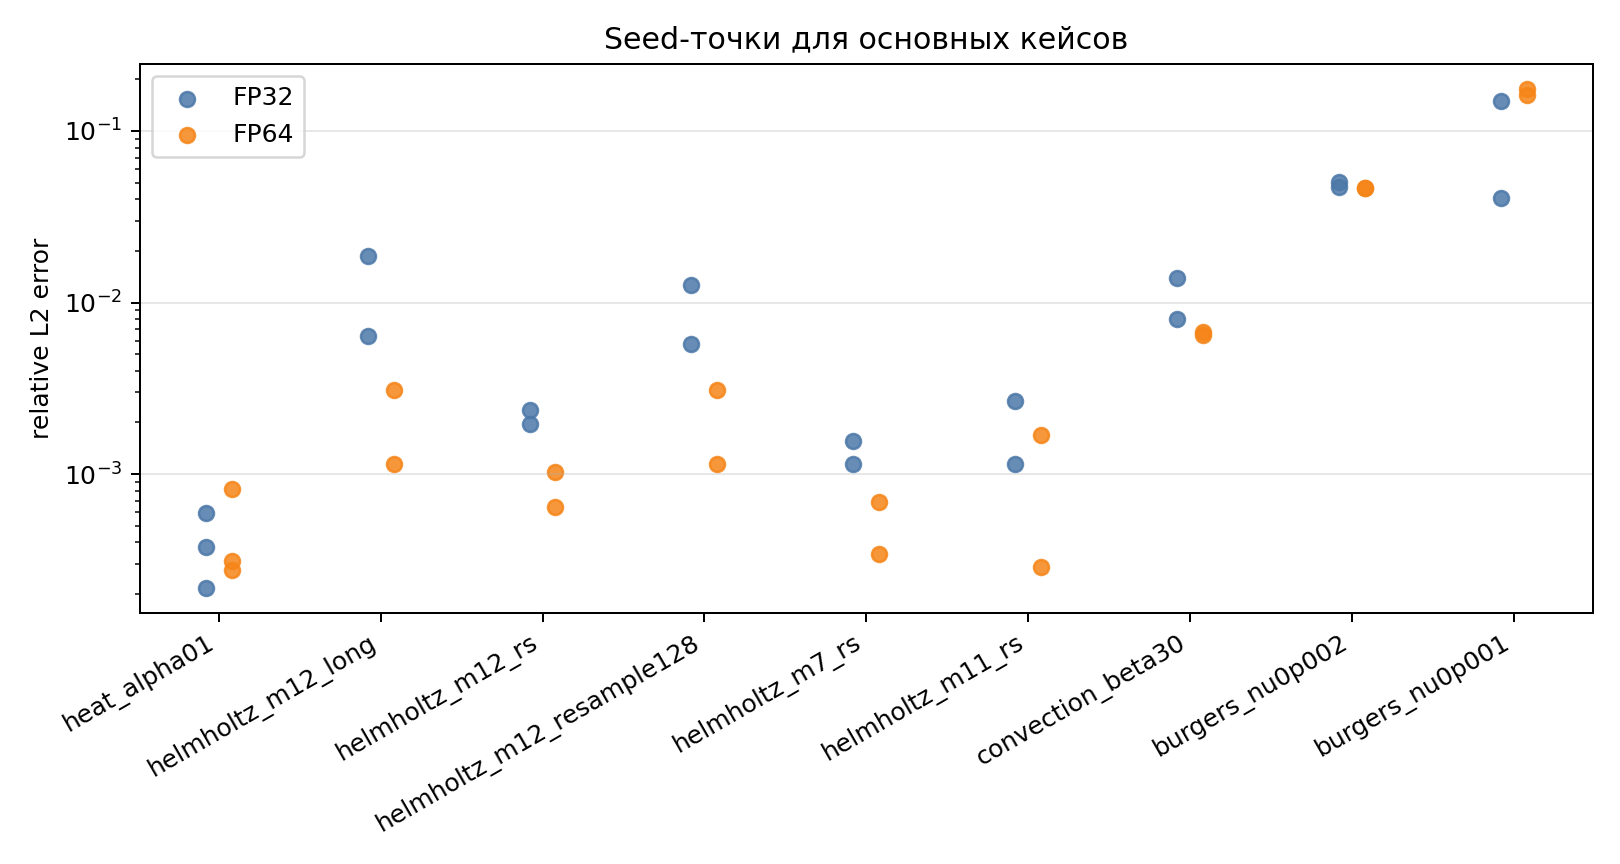

In [17]:
show_img("report_main_best_l2_by_dtype.png")
show_img("report_main_fp64_fp32_ratio.png")
show_img("report_main_seed_scatter.png")


Главный аккуратный вывод такой: FP64 заметно помогает на нескольких Helmholtz-запусках, но это не универсальное правило. Burgers и часть диагностических режимов показывают, что результат зависит от задачи, гиперпараметров и seed.
